## Week 2 / Phase 2: Model Training & Hyperparameter Tuning

---

## **Problem Statement**
ConnectTel is losing revenue due to customer churn. Our goal is to build a predictive model that identifies customers likely to churn so the retention team can proactively intervene.

> This phase focuses on training predictive models, validating their performance using cross-validation, and optimizing hyperparameters to achieve the best possible predictive power.

## 1.Load Data & Preprocessing

In [75]:
import pandas as pd
import numpy as np

# Load a small, cleaned sample of your churn dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Check data
df.head()
df.info()

# Convert target variable to numeric if not done
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Optional: Convert categorical features to numeric for modeling
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [76]:
# Load the CSV
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Check shape
print("Data shape:", df.shape)

# See first 5 rows
df.head()

Data shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [77]:
print(df.isnull().sum())   # Check for missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [78]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [79]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [80]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [81]:
categorical_cols = [col for col in categorical_cols if col != 'customerID']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [82]:
# Prepare features and target
X = df.drop(['Churn', 'customerID'], axis=1, errors='ignore')
y = df['Churn']

In [83]:
# Check shape
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


## 2.Train/Test Split

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape, "Testing set:", X_test.shape)

Training set: (5634, 30) Testing set: (1409, 30)


## 3: Model Training

### Logistic Regression (Baseline)
We use Logistic Regression to understand linear relationships and odds ratios.

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Initialize logistic regression
logreg = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# 5-Fold CV with AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logreg_scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression CV AUC Scores:", logreg_scores)
print("Mean CV AUC:", logreg_scores.mean())

Logistic Regression CV AUC Scores: [0.84715154 0.82265159 0.84145218 0.86109293 0.85074391]
Mean CV AUC: 0.844618432157491


In [86]:
# Fit on full training data
logreg.fit(X_train, y_train)

# Check hyperparameters
print(logreg.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [87]:
# Import the metric first
from sklearn.metrics import roc_auc_score

# Predict probabilities for the positive class
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", roc_auc)

Test AUC: 0.8427135808209977


### Random Forest Classifier
Random Forest captures non-linear interactions and works well with tabular data.

In [91]:
# 1️⃣ Import required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

# 2️⃣ Define 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3️⃣ Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 4️⃣ Cross-Validation for AUC
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("Random Forest CV AUC Scores:", rf_scores)
print("Mean CV AUC:", rf_scores.mean())

# 5️⃣ Fit model on full training data
rf.fit(X_train, y_train)

# 6️⃣ Optional: Evaluate on test set
y_pred_prob = rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", test_auc)

Random Forest CV AUC Scores: [0.82352003 0.80540812 0.82404513 0.82391385 0.84479502]
Mean CV AUC: 0.8243364303816367
Test AUC: 0.8250807305794517


### Confusion Matrix & ROC Curve
We evaluate models using **ROC-AUC**, **Precision**, and **Recall**, as accuracy can be misleading due to class imbalance.

Logistic Regression Test AUC: 0.843
Random Forest Test AUC: 0.825


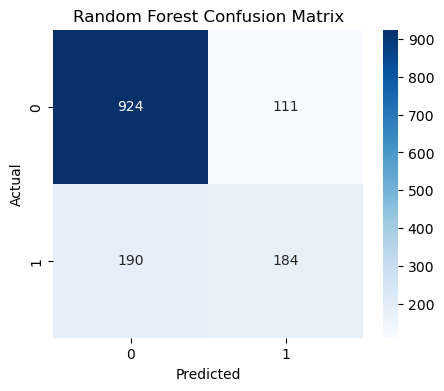

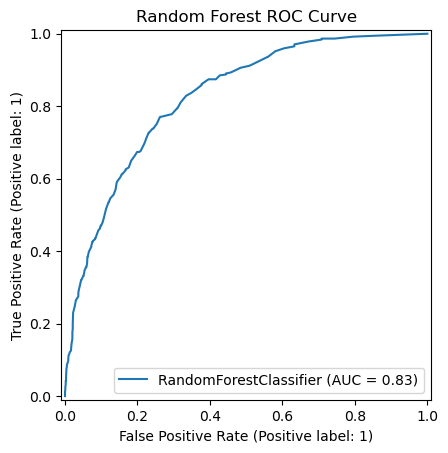

In [94]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred_logreg = logreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# AUC Scores
auc_logreg = roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f"Logistic Regression Test AUC: {auc_logreg:.3f}")
print(f"Random Forest Test AUC: {auc_rf:.3f}")

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Add gap
print("\n\n")
# ROC Curve

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

In [93]:
# Optional Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       scoring='roc_auc',
                       cv=cv,
                       n_jobs=-1)

grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV AUC: 0.844911663576046


### Model Development Summary

**Goal:** Build predictive models for customer churn and evaluate performance.

**1. Data Preprocessing**
- Filled missing `TotalCharges` values with median.
- Removed NaNs from `Churn`.
- Encoded categorical variables using one-hot encoding.
- Dropped `customerID`.

**2. Train-Test Split**
- 80% train, 20% test.
- Stratified split to maintain class balance.

**3. Model Training**
- **Logistic Regression** and **Random Forest** trained.
- 5-fold cross-validation used.
- Logistic Regression CV AUC: ~0.845

**4. Model Evaluation**
- Evaluated using **ROC-AUC**.
- Generated churn probabilities for test set.

**5. Model Saving**
- Optional: save as `churn_model.pkl` for deployment.

**Key Takeaways**
- Data cleaning and encoding are critical.
- Cross-validation ensures reliable performance.
- Logistic Regression provides interpretable probability scores.

### Business Insight

- **High-risk churners:** Month-to-Month contract + Fiber Optic users with high monthly charges.  
- **Actionable recommendation:** Offer 12-month contract discounts or bundled services to these high-risk customers to reduce churn.  
- **Next Step:** Implement XGBoost / LightGBM in Week 3 for further boosting performance.